# Spectral filtering of Raman soliton dynamics

This example shows how to use the code for single-mode GNLSE propagation.

In [1]:
using Pkg

ROOT = abspath(joinpath(@__DIR__, ".."))
Pkg.activate(ROOT)

using PulsePropagation
using FFTW
using LinearAlgebra
using PyPlot
using DelimitedFiles

  Activating project at `~/FastDifferentiableMMNLO`


Setting degrees_of_freedom(:time) sets the simulation up to not include space and polarization degrees of freedom. Note however that the way things are done in this code, the field array will have dimension = 1 in the space and polarization directions (rather than being altogether absent). Note that time_grid is strictly necessary to instantiate a simulation, but for convenience we construct the time/frequency/wavelength grid.

In [2]:
c_light = 2.99792458e-4; # m/ps -- see manual for unit system info
Nt = 2^12;
time_window = 50; # ps
λ0 = 1550e-9; # m
ω0 = 2*π*c_light/λ0;

time_grid = TimeGrid(Nt,time_window);
t = time_axis(time_grid);
Ω = frequency_axis(time_grid); # constructs relative frequency
ω = ω0 .+ Ω; # absolute frequency;
f = ω / (2*π);
λ = wavelength_axis(time_grid,ω0); # wavelength
λ_nm = λ/1e-9; # wavelength

dofs = degrees_of_freedom(:time)
domain = MMGNLSEDomain(dofs, time_grid);


Below we setup a single-mode fiber. The nonlinear parameter fed into the simulation in the multimode case is a mode overlap tensor with dimensions of inverse area. For the single-mode case, the correct quantity to feed in is the inverse mode area. Note that for the Raman model, the default parameters are Raman fraction of 0.18, tau1 (oscillation frequency) of 12.2 fs, tau2 (decay) of 32 fs. 

In [3]:
material = Silica(raman=AgarwalRaman()) # The default Silica picks an anisotropic Raman model. See other notebooks such as soliton_jitter for other Raman models;
mfd = 9.2e-6; # mode-field diameter.
Aeff= π * (mfd / 2)^2;
fiber_length = 10;

beta2 = -2.06e-26 * 1e24;
beta3 = 8.1038e-41 * 1e36;
betas = reshape([0.0, 0.0, beta2, beta3], :, 1);

Initial field is setup below.

In [4]:
peak_power = 3655.7;
pulse_fwhm = 0.22;
pulse_tau = pulse_fwhm / (2*acosh(sqrt(2)));

initial_field = zeros(Nt,1,1);
initial_field[:,1,1] .= sqrt(peak_power)*sech.(t/pulse_tau);

MMGNLSE parameters are fed into the simulation here. One small type compatibility note that is not obvious: the dispersion type expected is a TaylorBeta() object. A dispersion array can be converted into the correct type as shown below. 

In [5]:
parameters = MMGNLSEParameters(domain;
length=fiber_length,
beta=TaylorBeta(betas),
S=1/Aeff,
n2=2.3e-20,
omega0=2*π*c_light / λ0,
raman=AgarwalRaman())

MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, SpatialOverlap{Float64}, Float64, Float64, AgarwalRaman{Float64}}(MMGNLSEDomain{TimeGrid{Float64}}(DegreesOfFreedom(:time), TimeGrid{Float64}(4096, 0.01220703125)), 10.0, [0;;;;], [0;;;;], TaylorBeta{Float64, 2}([0.0; 0.0; -0.0206; 8.1038e-5;;]), SpatialOverlap{Float64}([1.5043000292239635e10;;;;]), 2.3e-20, 1215.2590756831312, AgarwalRaman{Float64}(0.18, 0.0122, 0.032))

Forward solution and visualization.

In [6]:
dz = 0.001;
solution = solve_mmgnlse(initial_field, parameters, dz; saveat=0.001);

At_final = get_temporal_field(solution)
Aomega_final = get_spectral_field(solution)
z_saved = solution.z;

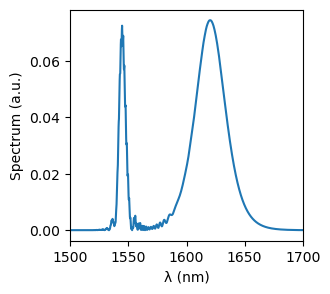

In [7]:
figure(figsize=(3,3))
plot(λ_nm,abs2.(Aomega_final[:,1,1]))
xlim(1500,1700)
xlabel("λ (nm)")
ylabel("Spectrum (a.u.)")
display(gcf())

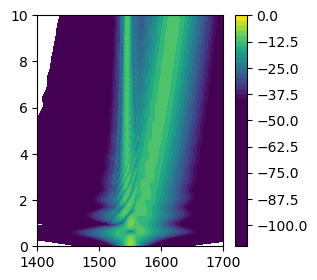

In [8]:
spec_z = abs2.(ifftshift(ifft(solution.fields, 1),1))
figure(figsize=(3,3))
contourf(λ_nm,solution.z,10log10.(spec_z[:,1,1,:]'),levels=[-110:2.5:0;])
clim(-40,0)
xlim(1400,1700)
colorbar()
display(gcf())

This part of this code shows the adjoint functionality. Here we consider the photon number variance associated with a filter that picks out a small window around the Raman soliton peak at around 1620 nm.

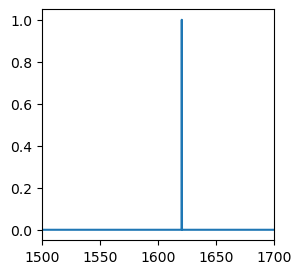

In [9]:
peak_pass_ind = argmax(abs2.(Aomega_final[:,1,1]))
filter = zeros(length(λ));
filter[peak_pass_ind] = 1.0;

figure(figsize=(3,3))
plot(λ_nm, filter)
xlim(1500,1700)
display(gcf())

Sets up the observable of interest (photon number), constructs a terminal condition for the adjoint equation (adjoint field at the end of the fiber) and backpropagates to $z=0$ to give the gradient of the output photon number with respect to the initial conditions.

In [10]:
peak_photon_number =  SpectralPhotonNumber(filter=filter, modes=:all);
filter_mean = value(peak_photon_number, solution)
lambda_L = terminal_condition(peak_photon_number, solution);

In [ ]:
dz_adj = 0.001;
adjoint = solve_adjoint(lambda_L, parameters, dz_adj; forward_solution=solution)
peak_sensitivity = get_spectral_field(adjoint; units=:photon)[:,:,1];

In [ ]:
filter_var = sum(abs2.(peak_sensitivity));
fano = filter_var / filter_mean
println("The Fano factor of the Raman soliton is $(fano)")

In [ ]:
figure(figsize=(3,3))
semilogy(λ_nm, abs2.(peak_sensitivity))
xlim(1500,1700)
ylim(1)
xlabel("λ (nm)")
ylabel("Raman peak sensitivity |∂n/∂α|²")
display(gcf())

Same idea but for a more complex filter that leverages anticorrelations between different spectral components to generate squeezing at the output.

In [ ]:
opt_filt_trunc = readdlm("benchmark_data/squeezing_spectral_filter/optimal_filter.csv");
opt_filt = zeros(Nt);
opt_filt[1196:2371] = reverse(opt_filt_trunc); 

figure(figsize=(3,3))
plot(λ_nm, opt_filt)
xlim(1550,1700)
display(gcf())

In [15]:
filtered_photon_number = SpectralPhotonNumber(filter=opt_filt);
filter_mean = value(filtered_photon_number, solution)
lambda_L = terminal_condition(filtered_photon_number, solution);

dz_adj = 0.001;
adjoint = solve_adjoint(lambda_L, parameters, dz_adj; forward_solution=solution, saveat=0.01)
filtered_sensitivity = get_spectral_field(adjoint; units=:photon)[:,:,1];

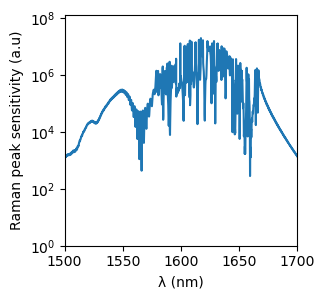

In [16]:
figure(figsize=(3,3))
semilogy(λ_nm, abs2.(filtered_sensitivity))
xlim(1500,1700)
ylim(1)
xlabel("λ (nm)")
ylabel("Raman peak sensitivity (a.u)")
display(gcf())

In [17]:
filter_var = sum(abs2.(filtered_sensitivity));
fano = filter_var / filter_mean
println("The Fano factor of the Raman soliton is $(fano)")

The Fano factor of the Raman soliton is 0.21594203646370688


Noise-immunity of the correlations: if we add 10x excess noise at the pump, the output noise changes much less (~1.5x) corresponding to about 5 dB squeezing. 

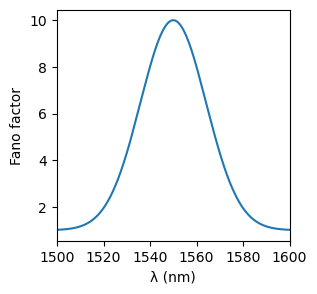

In [18]:
F0, λ0, Δλ = 9, 1550, 20;
fano_list = F0*exp.(-(λ_nm .- λ0) .^2 ./ (Δλ)^2) .+ 1;

figure(figsize=(3,3))
plot(λ_nm,fano_list)
xlim(1500,1600)
xlabel("λ (nm)")
ylabel("Fano factor")
display(gcf())

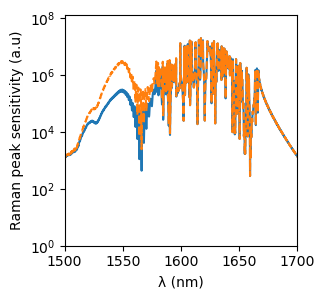

In [19]:
figure(figsize=(3,3))
semilogy(λ_nm, abs2.(filtered_sensitivity))
semilogy(λ_nm, fano_list .* abs2.(filtered_sensitivity), "--")
xlim(1500,1700)
ylim(1)
xlabel("λ (nm)")
ylabel("Raman peak sensitivity (a.u)")
display(gcf())

In [20]:
var_with_noise = sum(fano_list .* abs2.(filtered_sensitivity));
fano_with_noise = var_with_noise/filter_mean;

The adjoint calculation above doesn't take into account noise added by Raman scattering. The added noise contribution from Raman can be computed using the same adjoint and weighting it by Raman correlations as shown below.  We're recalculating the adjoint here because we want the units of the complex field in the derivative ("denominator units") to be sqrt-power units rather than photon units. We could retain it in photon units but then we would have to compute the field in photon units.

In [21]:
filtered_photon_number = SpectralPhotonNumber(filter=opt_filt);
filter_mean = value(filtered_photon_number, solution)
lambda_L = terminal_condition(filtered_photon_number, solution);

dz_adj = 0.001;
adjoint = solve_adjoint(lambda_L, parameters, dz_adj; forward_solution=solution, saveat=0.001)
filtered_sensitivity = get_spectral_field(adjoint)[:,:,1];

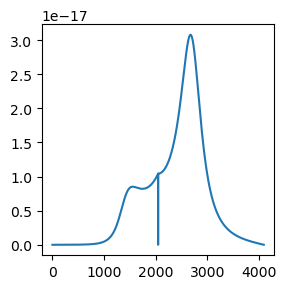

In [22]:
gamma = parameters.n2 * parameters.omega0 / c_light / Aeff  # W^-1 m^-1
dt = diff(t)[1];
f0 = ω0/(2*π);

fR = parameters.raman.fraction
tau1 = parameters.raman.tau1;
tau2 = parameters.raman.tau2;

temp = 300.0;

Cω = PulsePropagation.raman_langevin_spectrum(
    Nt, dt, f0, gamma;
    raman_fraction=parameters.raman.fraction,
    temperature_K=temp,
)

Cω = ifftshift(Cω)

figure(figsize=(3,3))
plot(abs.(Cω))
display(gcf())

In [23]:
Azt = get_temporal_field(solution; z=:all, units=:power);
λzt = conj(get_temporal_field(adjoint; z=:all, units=:power));
Bzt = -2*imag(Azt .* λzt);
Bzω = ifftshift(ifft(Bzt,1));
Δz = diff(adjoint.z)[1];
dn2_raman = gamma^2 * sum(abs2.(Bzω) .* Cω) * (diff(f)[1] * 1e12) * Δz

2.4217296001838747e8

In [24]:
fano_with_raman = (filter_var + dn2_raman)/filter_mean

0.2670718760172193